### IMPORT

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### IMPORT CSV

In [2]:
df = pd.read_excel('Concrete_Data.xls', engine='xlrd')

In [6]:
from scipy.stats import chi2


def detect_outliers_hampel(df, columns=None, threshold=3, show_summary=True):
    """
    Phát hiện outliers cho tất cả các cột sử dụng Hampel Filter / MAD.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame chứa dữ liệu
    columns : list, optional
        Danh sách tên cột cần kiểm tra. Nếu None, kiểm tra tất cả cột số
    threshold : float, default=3
        Ngưỡng MAD (thường dùng 3)
    show_summary : bool, default=True
        Hiển thị tóm tắt kết quả
    
    Returns:
    --------
    dict : Dictionary chứa kết quả
        {
            'outlier_summary': dict với thông tin chi tiết từng cột,
            'all_outliers_mask': boolean array của các mẫu có ít nhất 1 outlier,
            'clean_mask': boolean array của các mẫu không có outlier nào,
            'df_clean': DataFrame sau khi loại bỏ outliers,
            'df_outliers': DataFrame chỉ chứa các outliers
        }
    """
    
    # Nếu không chỉ định columns, lấy tất cả cột số
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()
    
    def hampel_filter_mad(data, threshold=3):
        """Phát hiện outliers bằng Hampel Filter / MAD"""
        median = np.median(data)
        mad = np.median(np.abs(data - median))
        
        # Công thức chuẩn hóa MAD
        mad_std = 1.4826 * mad
        
        # Tính modified z-score
        if mad_std != 0:
            modified_z_scores = (data - median) / mad_std
        else:
            modified_z_scores = np.zeros_like(data) 
        
        outliers_mask = np.abs(modified_z_scores) > threshold
        
        return outliers_mask, mad, median
    
    outlier_summary = {}
    all_outliers_mask = np.zeros(len(df), dtype=bool)
    
    if show_summary:
        print("\n" + "="*70)
        print("KẾT QUẢ PHÁT HIỆN OUTLIERS (HAMPEL FILTER / MAD)")
        print("="*70)
    
    for feature in columns:
        outliers_mask, mad, median = hampel_filter_mad(df[feature].values, threshold)
        
        num_outliers = outliers_mask.sum()
        outlier_percentage = (num_outliers / len(df)) * 100
        
        outlier_summary[feature] = {
            'count': num_outliers,
            'percentage': outlier_percentage,
            'mad': mad,
            'median': median,
            'mask': outliers_mask,
            'outlier_indices': np.where(outliers_mask)[0].tolist()
        }
        
        # Cộng dồn mask
        all_outliers_mask |= outliers_mask
        
        if show_summary:
            print(f"\n{feature}:")
            print(f"  Median: {median:.2f}")
            print(f"  MAD: {mad:.2f}")
            print(f"  Số outliers: {num_outliers} ({outlier_percentage:.1f}%)")
            
            if num_outliers > 0:
                outlier_values = df[feature].values[outliers_mask]
                print(f"  Giá trị outliers: min={outlier_values.min():.2f}, max={outlier_values.max():.2f}")
    
    # Tạo mask cho dữ liệu sạch (không có outlier)
    clean_mask = ~all_outliers_mask
    
    if show_summary:
        print("\n" + "="*70)
        print(f"TỔNG SỐ MẪU CÓ ÍT NHẤT 1 OUTLIER: {all_outliers_mask.sum()} ({all_outliers_mask.sum()/len(df)*100:.1f}%)")
        print(f"TỔNG SỐ MẪU SẠCH (KHÔNG CÓ OUTLIER): {clean_mask.sum()} ({clean_mask.sum()/len(df)*100:.1f}%)")
        print("="*70)
    
    return {
        'outlier_summary': outlier_summary,
        'all_outliers_mask': all_outliers_mask,
        'clean_mask': clean_mask,
        'df_clean': df[clean_mask].copy(),
        'df_outliers': df[all_outliers_mask].copy(),
        'threshold': threshold,
        'columns_checked': columns
    }


def visualize_outliers(df, outlier_results, figsize=(15, 10)):
    """
    Trực quan hóa outliers bằng boxplot.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame gốc
    outlier_results : dict
        Kết quả từ detect_outliers_hampel()
    figsize : tuple, default=(15, 10)
        Kích thước figure
    """
    columns = outlier_results['columns_checked']
    n_cols = 3
    n_rows = int(np.ceil(len(columns) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if len(columns) > 1 else [axes]
    
    for idx, col in enumerate(columns):
        ax = axes[idx]
        
        # Boxplot
        bp = ax.boxplot(df[col], vert=True, patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        
        # Đánh dấu outliers
        outlier_mask = outlier_results['outlier_summary'][col]['mask']
        if outlier_mask.sum() > 0:
            outlier_values = df[col].values[outlier_mask]
            outlier_positions = np.ones(len(outlier_values))
            ax.scatter(outlier_positions, outlier_values, color='red', 
                      s=50, alpha=0.6, label='Outliers', zorder=5)
        
        # Thông tin
        num_outliers = outlier_results['outlier_summary'][col]['count']
        percentage = outlier_results['outlier_summary'][col]['percentage']
        
        ax.set_title(f'{col}\nOutliers: {num_outliers} ({percentage:.1f}%)', 
                    fontsize=10, fontweight='bold')
        ax.set_ylabel('Giá trị', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        if outlier_mask.sum() > 0:
            ax.legend(fontsize=8)
    
    # Ẩn subplot thừa
    for idx in range(len(columns), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Phát hiện Outliers - Hampel Filter/MAD', 
                fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()


def compare_datasets(df_original, df_clean, title_prefix=""):
    """
    So sánh dataset gốc và dataset sau khi loại bỏ outliers.
    
    Parameters:
    -----------
    df_original : pandas.DataFrame
        DataFrame gốc
    df_clean : pandas.DataFrame
        DataFrame đã loại bỏ outliers
    title_prefix : str, optional
        Tiền tố cho tiêu đề
    """
    print("\n" + "="*70)
    print(f"{title_prefix}SO SÁNH DATASET")
    print("="*70)
    print(f"Dataset gốc: {len(df_original)} mẫu")
    print(f"Dataset sạch: {len(df_clean)} mẫu")
    print(f"Số mẫu bị loại bỏ: {len(df_original) - len(df_clean)} ({(1 - len(df_clean)/len(df_original))*100:.1f}%)")
    print("="*70)
    
    print("\nThống kê mô tả - DATASET GỐC:")
    print(df_original.describe())
    
    print("\nThống kê mô tả - DATASET SẠCH:")
    print(df_clean.describe())

def detect_outliers_multivariate_pca(df, features=None, variance_threshold=0.95, 
                                      alpha=0.01, show_info=True, show_plots=True):
    """
    Phát hiện outliers đa biến sử dụng PCA (Hotelling T² và Q-statistic).
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame chứa dữ liệu
    features : list, optional
        Danh sách tên cột để phân tích. Nếu None, dùng tất cả cột số
    variance_threshold : float, default=0.95
        Ngưỡng phương sai tích lũy để chọn số PC (0.95 = 95%)
    alpha : float, default=0.01
        Mức ý nghĩa thống kê (0.01 = 99% confidence)
    show_info : bool, default=True
        Hiển thị thông tin chi tiết
    show_plots : bool, default=True
        Hiển thị biểu đồ
    
    Returns:
    --------
    dict : Dictionary chứa kết quả
        {
            'T2': array của Hotelling T² values,
            'Q': array của Q-statistic values,
            'T2_threshold': ngưỡng T²,
            'Q_threshold': ngưỡng Q,
            'T2_outliers_mask': boolean mask cho T² outliers,
            'Q_outliers_mask': boolean mask cho Q outliers,
            'multivariate_outliers_mask': boolean mask kết hợp,
            'df_clean': DataFrame sau khi loại bỏ outliers,
            'pca': PCA object đã fit,
            'scaler': StandardScaler object đã fit,
            'n_pc': số PC được sử dụng,
            'explained_variance_ratio': tỷ lệ phương sai giải thích
        }
    """
    
    # Nếu không chỉ định features, lấy tất cả cột số
    if features is None:
        features = df.select_dtypes(include=[np.number]).columns.tolist()
    
    if show_info:
        print(f"\n{'='*70}")
        print("PHÁT HIỆN OUTLIERS ĐA BIẾN (PCA - Hotelling T² và Q-statistic)")
        print(f"{'='*70}")
    
    # Chuẩn bị dữ liệu
    X = df[features].values
    
    # Chuẩn hóa dữ liệu (mean=0, std=1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Áp dụng PCA
    n_components = len(features)
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    if show_info:
        print(f"\nSố components: {n_components}")
        print(f"Phương sai giải thích bởi từng PC:")
        for i, var in enumerate(pca.explained_variance_ratio_):
            print(f"  PC{i+1}: {var*100:.2f}%")
        print(f"Tổng phương sai giải thích: {pca.explained_variance_ratio_.sum()*100:.2f}%")
    
    # Chọn số PC để giữ lại
    cumsum_var = np.cumsum(pca.explained_variance_ratio_)
    n_pc = np.argmax(cumsum_var >= variance_threshold) + 1
    
    if show_info:
        print(f"\nSố PC cần để giữ {variance_threshold*100:.0f}% variance: {n_pc}")
    
    # ----- HOTELLING T² STATISTIC -----
    n_samples = X_pca.shape[0]
    
    # Tính T² cho từng mẫu
    T2 = np.sum((X_pca[:, :n_pc] ** 2) / pca.explained_variance_[:n_pc], axis=1)
    
    # Ngưỡng T² (dựa trên phân phối F)
    from scipy.stats import f
    T2_threshold = (n_pc * (n_samples - 1) * (n_samples + 1)) / \
                   (n_samples * (n_samples - n_pc)) * \
                   f.ppf(1 - alpha, n_pc, n_samples - n_pc)
    
    T2_outliers = T2 > T2_threshold
    n_T2_outliers = T2_outliers.sum()
    
    if show_info:
        print(f"\n--- Hotelling T² Statistic ---")
        print(f"Số PC sử dụng: {n_pc}")
        print(f"Ngưỡng T² (α={alpha}): {T2_threshold:.2f}")
        print(f"T² max: {T2.max():.2f}")
        print(f"Số outliers phát hiện: {n_T2_outliers} ({n_T2_outliers/n_samples*100:.1f}%)")
    
    # ----- Q-STATISTIC (SPE - Squared Prediction Error) -----
    X_reconstructed = pca.inverse_transform(X_pca)
    Q = np.sum((X_scaled - X_reconstructed) ** 2, axis=1)
    
    # Ngưỡng Q (công thức Jackson-Mudholkar)
    theta = [np.sum(pca.explained_variance_[n_pc:] ** i) for i in range(1, 4)]
    h0 = 1 - (2 * theta[0] * theta[2]) / (3 * theta[1] ** 2)
    
    Q_threshold = theta[0] * (
        1 - (theta[1] * h0 * (1 - h0)) / theta[0] ** 2 +
        chi2.ppf(1 - alpha, h0 ** 2) * np.sqrt(2 * theta[1] * h0 ** 2) / theta[0]
    ) ** (1 / h0)
    
    Q_outliers = Q > Q_threshold
    n_Q_outliers = Q_outliers.sum()
    
    if show_info:
        print(f"\n--- Q-statistic (SPE) ---")
        print(f"Ngưỡng Q (α={alpha}): {Q_threshold:.2f}")
        print(f"Q max: {Q.max():.2f}")
        print(f"Số outliers phát hiện: {n_Q_outliers} ({n_Q_outliers/n_samples*100:.1f}%)")
    
    # Kết hợp cả hai tiêu chí
    multivariate_outliers = T2_outliers | Q_outliers
    n_multi_outliers = multivariate_outliers.sum()
    
    if show_info:
        print(f"\n--- Kết hợp T² và Q ---")
        print(f"Tổng số outliers đa biến: {n_multi_outliers} ({n_multi_outliers/n_samples*100:.1f}%)")
    
    # Visualization
    if show_plots:
        _plot_pca_outliers(T2, Q, T2_threshold, Q_threshold, 
                          T2_outliers, Q_outliers, 
                          n_T2_outliers, n_Q_outliers)
    
    # DataFrame sạch
    df_clean = df[~multivariate_outliers].copy()
    
    return {
        'T2': T2,
        'Q': Q,
        'T2_threshold': T2_threshold,
        'Q_threshold': Q_threshold,
        'T2_outliers_mask': T2_outliers,
        'Q_outliers_mask': Q_outliers,
        'multivariate_outliers_mask': multivariate_outliers,
        'df_clean': df_clean,
        'df_outliers': df[multivariate_outliers].copy(),
        'pca': pca,
        'scaler': scaler,
        'n_pc': n_pc,
        'explained_variance_ratio': pca.explained_variance_ratio_,
        'X_pca': X_pca,
        'n_outliers': n_multi_outliers,
        'outlier_percentage': n_multi_outliers/n_samples*100,
        'features': features,
        'alpha': alpha
    }


def _plot_pca_outliers(T2, Q, T2_threshold, Q_threshold, 
                       T2_outliers, Q_outliers, 
                       n_T2_outliers, n_Q_outliers):
    """Helper function để vẽ biểu đồ PCA outliers"""
    
    # Plot 1 & 2: T² chart và Q chart
    fig_pca, axes_pca = plt.subplots(1, 2, figsize=(16, 6))
    
    indices = np.arange(len(T2))
    
    # Plot 1: T² chart
    ax1 = axes_pca[0]
    normal_indices = indices[~T2_outliers]
    outlier_indices = indices[T2_outliers]
    
    ax1.scatter(normal_indices, T2[~T2_outliers], c='steelblue', alpha=0.6, s=30, 
               label='Bình thường', edgecolors='black', linewidth=0.5)
    if n_T2_outliers > 0:
        ax1.scatter(outlier_indices, T2[T2_outliers], 
                   c='red', alpha=0.8, s=80, label='Outliers', 
                   edgecolors='darkred', linewidth=1.5, marker='X')
    ax1.axhline(y=T2_threshold, color='orange', linestyle='--', linewidth=2, 
               label=f'Ngưỡng T² = {T2_threshold:.2f}')
    ax1.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Hotelling T²', fontsize=12, fontweight='bold')
    ax1.set_title(f'Hotelling T² Statistic\n({n_T2_outliers} outliers)', 
                 fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=10)
    
    # Plot 2: Q chart
    ax2 = axes_pca[1]
    normal_indices_q = indices[~Q_outliers]
    outlier_indices_q = indices[Q_outliers]
    
    ax2.scatter(normal_indices_q, Q[~Q_outliers], c='steelblue', alpha=0.6, s=30, 
               label='Bình thường', edgecolors='black', linewidth=0.5)
    if n_Q_outliers > 0:
        ax2.scatter(outlier_indices_q, Q[Q_outliers], 
                   c='red', alpha=0.8, s=80, label='Outliers', 
                   edgecolors='darkred', linewidth=1.5, marker='X')
    ax2.axhline(y=Q_threshold, color='orange', linestyle='--', linewidth=2, 
               label=f'Ngưỡng Q = {Q_threshold:.2f}')
    ax2.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Q-statistic (SPE)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Q-statistic (Squared Prediction Error)\n({n_Q_outliers} outliers)', 
                 fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Plot 3: T² vs Q scatter plot
    fig_scatter = plt.figure(figsize=(10, 8))
    ax_scatter = fig_scatter.add_subplot(111)
    
    # Vẽ 4 vùng
    both_normal = ~T2_outliers & ~Q_outliers
    only_T2 = T2_outliers & ~Q_outliers
    only_Q = ~T2_outliers & Q_outliers
    both_outlier = T2_outliers & Q_outliers
    
    ax_scatter.scatter(T2[both_normal], Q[both_normal], c='steelblue', alpha=0.6, 
                      s=40, label='Bình thường', edgecolors='black', linewidth=0.5)
    if only_T2.sum() > 0:
        ax_scatter.scatter(T2[only_T2], Q[only_T2], c='orange', alpha=0.7, 
                          s=60, label='Chỉ vi phạm T²', edgecolors='darkorange', linewidth=1, marker='s')
    if only_Q.sum() > 0:
        ax_scatter.scatter(T2[only_Q], Q[only_Q], c='purple', alpha=0.7, 
                          s=60, label='Chỉ vi phạm Q', edgecolors='indigo', linewidth=1, marker='^')
    if both_outlier.sum() > 0:
        ax_scatter.scatter(T2[both_outlier], Q[both_outlier], c='red', alpha=0.9, 
                          s=100, label='Vi phạm cả 2', edgecolors='darkred', linewidth=1.5, marker='X')
    
    ax_scatter.axhline(y=Q_threshold, color='orange', linestyle='--', linewidth=2, alpha=0.7)
    ax_scatter.axvline(x=T2_threshold, color='orange', linestyle='--', linewidth=2, alpha=0.7)
    ax_scatter.set_xlabel('Hotelling T²', fontsize=12, fontweight='bold')
    ax_scatter.set_ylabel('Q-statistic (SPE)', fontsize=12, fontweight='bold')
    ax_scatter.set_title('Biểu đồ T² vs Q\n(Phát hiện outliers đa biến)', 
                        fontsize=14, fontweight='bold')
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.legend(fontsize=10, loc='best')
    
    plt.tight_layout()
    plt.show()


def compare_outlier_removal(df_original, df_univariate, df_multivariate, 
                            target_col='COD_mgL', features=None):
    """
    So sánh các bước loại bỏ outliers.
    
    Parameters:
    -----------
    df_original : pandas.DataFrame
        DataFrame gốc
    df_univariate : pandas.DataFrame
        DataFrame sau khi loại outliers đơn biến
    df_multivariate : pandas.DataFrame
        DataFrame sau khi loại outliers đa biến
    target_col : str, default='COD_mgL'
        Tên cột target
    features : list, optional
        Danh sách features để so sánh correlation
    """
    
    if features is None:
        features = [col for col in df_original.columns if col != target_col]
    
    print(f"\n{'='*70}")
    print(f"DATASET CUỐI CÙNG (SAU KHI LOẠI BỎ CẢ OUTLIERS ĐƠN BIẾN VÀ ĐA BIẾN)")
    print(f"{'='*70}")
    print(f"Số mẫu ban đầu: {len(df_original)}")
    print(f"Sau loại outliers đơn biến: {len(df_univariate)} (loại bỏ {len(df_original) - len(df_univariate)})")
    print(f"Sau loại outliers đa biến: {len(df_multivariate)} (loại bỏ thêm {len(df_univariate) - len(df_multivariate)})")
    print(f"Tổng số mẫu bị loại: {len(df_original) - len(df_multivariate)} ({(len(df_original) - len(df_multivariate))/len(df_original)*100:.1f}%)")
    print(f"Số mẫu còn lại: {len(df_multivariate)} ({len(df_multivariate)/len(df_original)*100:.1f}%)")
    
    # So sánh correlation
    print(f"\n{'='*70}")
    print("SO SÁNH HỆ SỐ TƯƠNG QUAN:")
    print(f"{'='*70}")
    print(f"{'Feature':<25} {'Ban đầu':<12} {'Loại đơn':<12} {'Loại đa':<12}")
    print("-"*70)
    
    for feature in features:
        corr_original = df_original[target_col].corr(df_original[feature])
        corr_univariate = df_univariate[target_col].corr(df_univariate[feature])
        corr_multivariate = df_multivariate[target_col].corr(df_multivariate[feature])
        
        print(f"{feature:<25} {corr_original:>11.4f} {corr_univariate:>11.4f} {corr_multivariate:>11.4f}")
    
    print("="*70)


def full_outlier_pipeline(df, target_col='COD_mgL', 
                          hampel_threshold=3,
                          pca_variance=0.95,
                          pca_alpha=0.01,
                          show_info=True):
    """
    Pipeline đầy đủ: phát hiện và loại bỏ outliers đơn biến và đa biến.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame gốc
    target_col : str, default='COD_mgL'
        Tên cột target
    hampel_threshold : float, default=3
        Ngưỡng Hampel filter
    pca_variance : float, default=0.95
        Ngưỡng variance cho PCA
    pca_alpha : float, default=0.01
        Mức ý nghĩa thống kê cho PCA
    show_info : bool, default=True
        Hiển thị thông tin
    
    Returns:
    --------
    dict : Dictionary chứa tất cả kết quả
    """
    
    features = [col for col in df.columns if col != target_col]
    
    # Bước 1: Phát hiện outliers đơn biến
    if show_info:
        print("\n" + "="*70)
        print("BƯỚC 1: PHÁT HIỆN OUTLIERS ĐƠN BIẾN")
        print("="*70)
    
    univariate_results = detect_outliers_hampel(
        df, 
        columns=features,
        threshold=hampel_threshold,
        show_summary=show_info
    )
    
    df_after_univariate = univariate_results['df_clean']
    
    # Bước 2: Phát hiện outliers đa biến
    if show_info:
        print("\n" + "="*70)
        print("BƯỚC 2: PHÁT HIỆN OUTLIERS ĐA BIẾN")
        print("="*70)
    
    multivariate_results = detect_outliers_multivariate_pca(
        df_after_univariate,
        features=features,
        variance_threshold=pca_variance,
        alpha=pca_alpha,
        show_info=show_info,
        show_plots=show_info
    )
    
    df_final = multivariate_results['df_clean']
    
    # So sánh
    if show_info:
        compare_outlier_removal(df, df_after_univariate, df_final, 
                               target_col, features)
    
    return {
        'df_original': df,
        'df_after_univariate': df_after_univariate,
        'df_final': df_final,
        'univariate_results': univariate_results,
        'multivariate_results': multivariate_results,
        'total_removed': len(df) - len(df_final),
        'total_removed_pct': (len(df) - len(df_final)) / len(df) * 100
    }


KẾT QUẢ PHÁT HIỆN OUTLIERS (HAMPEL FILTER / MAD)

Cement:
  Median: 272.90
  MAD: 79.40
  Số outliers: 0 (0.0%)

Blast Furnace Slag:
  Median: 22.00
  MAD: 22.00
  Số outliers: 324 (31.5%)
  Giá trị outliers: min=120.00, max=359.40

Fly Ash:
  Median: 0.00
  MAD: 0.00
  Số outliers: 0 (0.0%)

Water:
  Median: 185.00
  MAD: 13.00
  Số outliers: 13 (1.3%)
  Giá trị outliers: min=121.75, max=247.00

Superplasticizer:
  Median: 6.35
  MAD: 5.31
  Số outliers: 5 (0.5%)
  Giá trị outliers: min=32.20, max=32.20

Coarse Aggregate:
  Median: 968.00
  MAD: 46.30
  Số outliers: 0 (0.0%)

Fine Aggregate:
  Median: 779.51
  MAD: 45.49
  Số outliers: 5 (0.5%)
  Giá trị outliers: min=992.60, max=992.60

Age:
  Median: 28.00
  MAD: 21.00
  Số outliers: 59 (5.7%)
  Giá trị outliers: min=180.00, max=365.00

Strength:
  Median: 34.44
  MAD: 10.93
  Số outliers: 0 (0.0%)

TỔNG SỐ MẪU CÓ ÍT NHẤT 1 OUTLIER: 387 (37.6%)
TỔNG SỐ MẪU SẠCH (KHÔNG CÓ OUTLIER): 643 (62.4%)


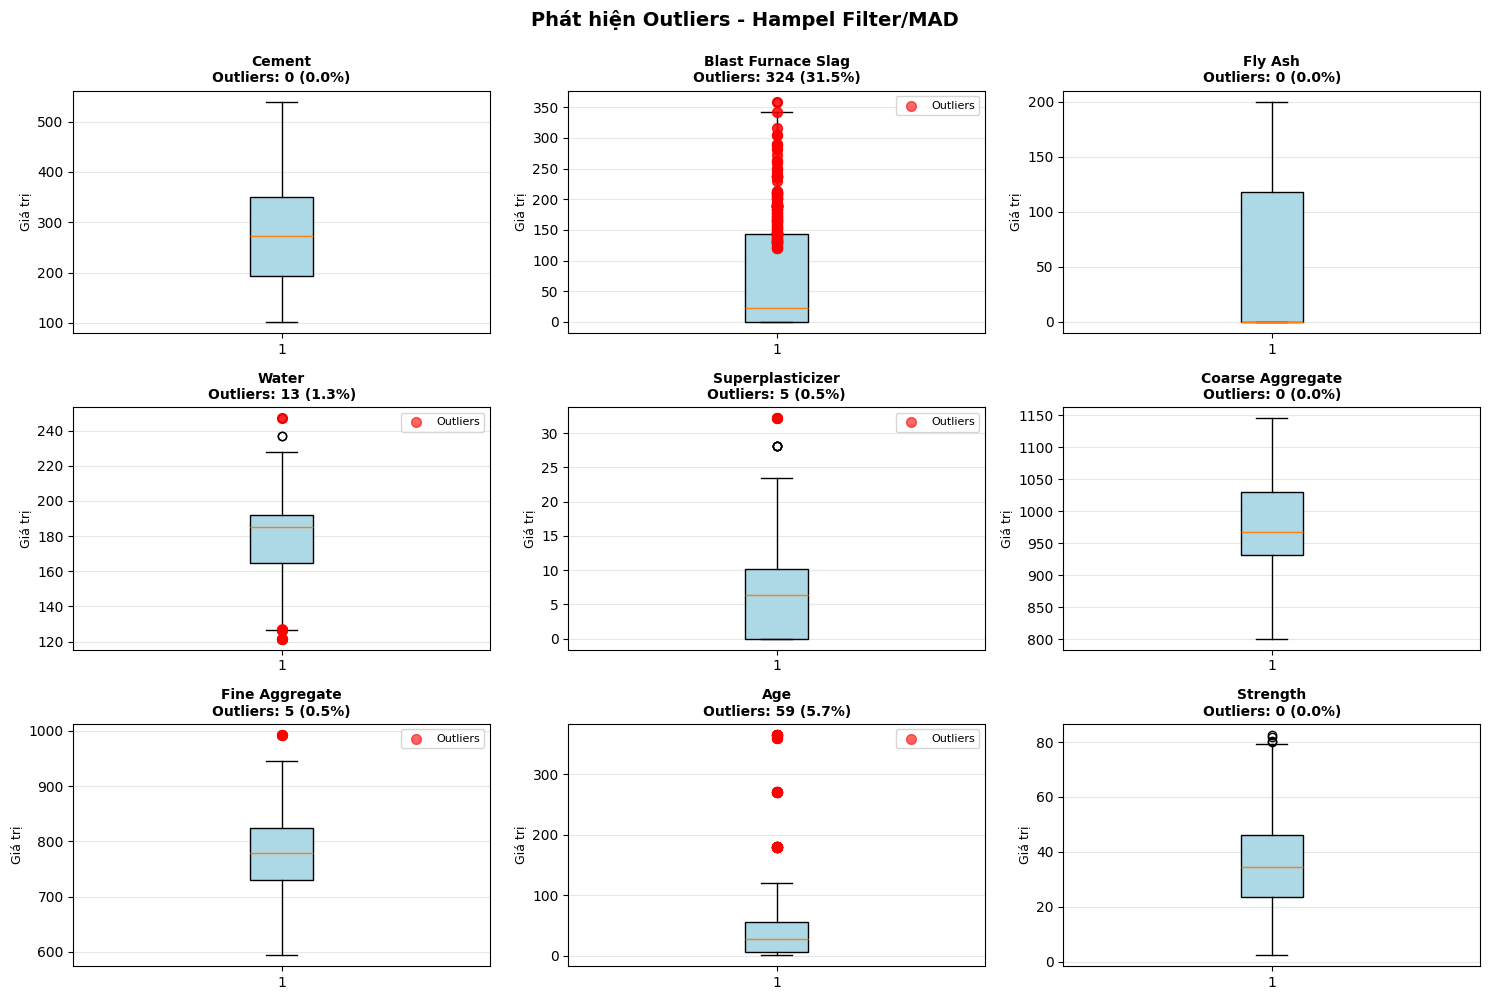

In [7]:
results = detect_outliers_hampel(df)
visualize_outliers(df,results)
df_clean = results['df_clean']


PHÁT HIỆN OUTLIERS ĐA BIẾN (PCA - Hotelling T² và Q-statistic)

Số components: 9
Phương sai giải thích bởi từng PC:
  PC1: 26.51%
  PC2: 22.62%
  PC3: 14.82%
  PC4: 11.90%
  PC5: 11.08%
  PC6: 8.96%
  PC7: 2.57%
  PC8: 1.10%
  PC9: 0.45%
Tổng phương sai giải thích: 100.00%

Số PC cần để giữ 95% variance: 6

--- Hotelling T² Statistic ---
Số PC sử dụng: 6
Ngưỡng T² (α=0.01): 17.14
T² max: 19.77
Số outliers phát hiện: 7 (1.1%)

--- Q-statistic (SPE) ---
Ngưỡng Q (α=0.01): 0.81
Q max: 0.00
Số outliers phát hiện: 0 (0.0%)

--- Kết hợp T² và Q ---
Tổng số outliers đa biến: 7 (1.1%)


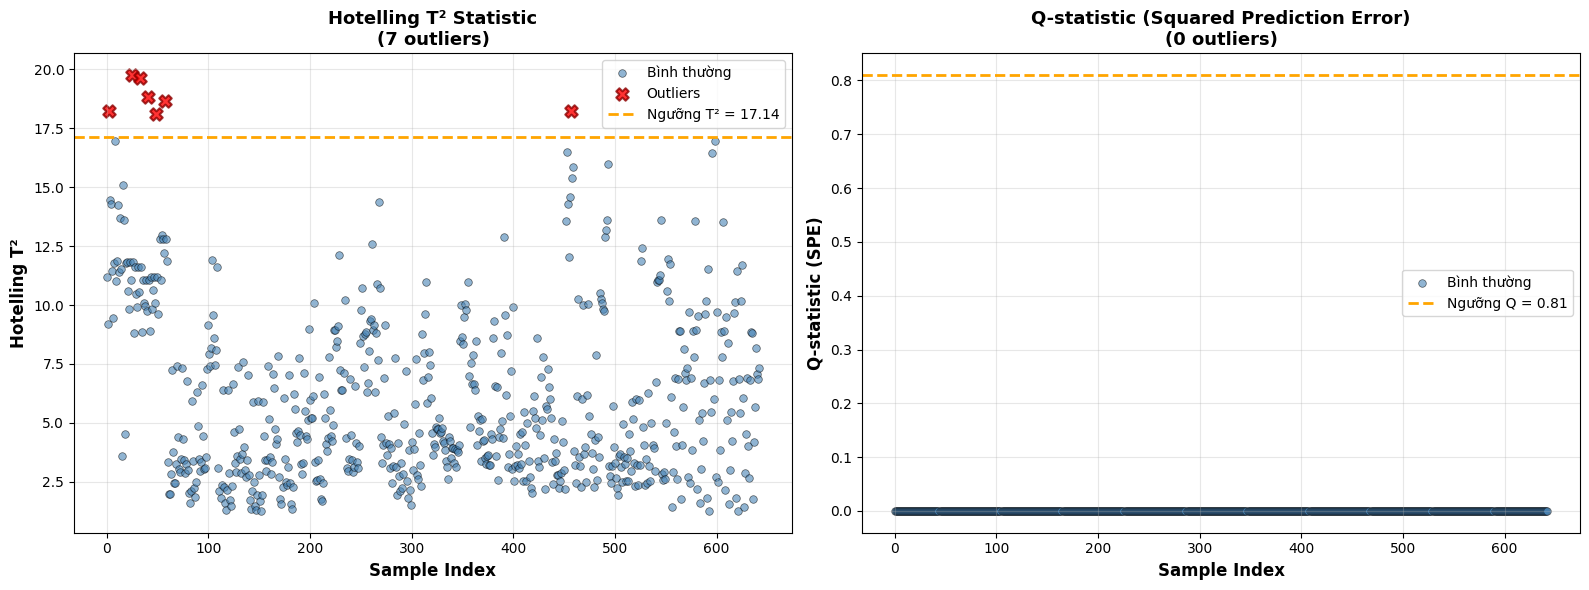

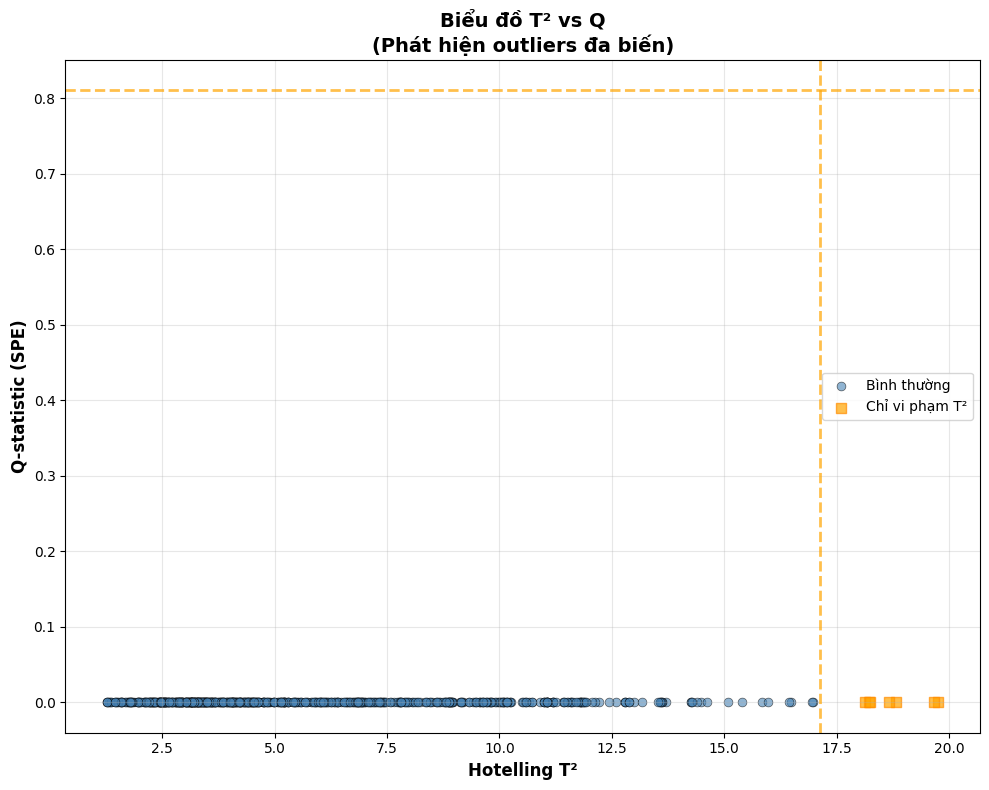

In [8]:
results = detect_outliers_multivariate_pca(df_clean)
df_final = results['df_clean']

Kích thước tập train: 381 (59.9%)
Kích thước tập validation: 127 (20.0%)
Kích thước tập test: 128 (20.1%)

Số thành phần tối ưu: 8


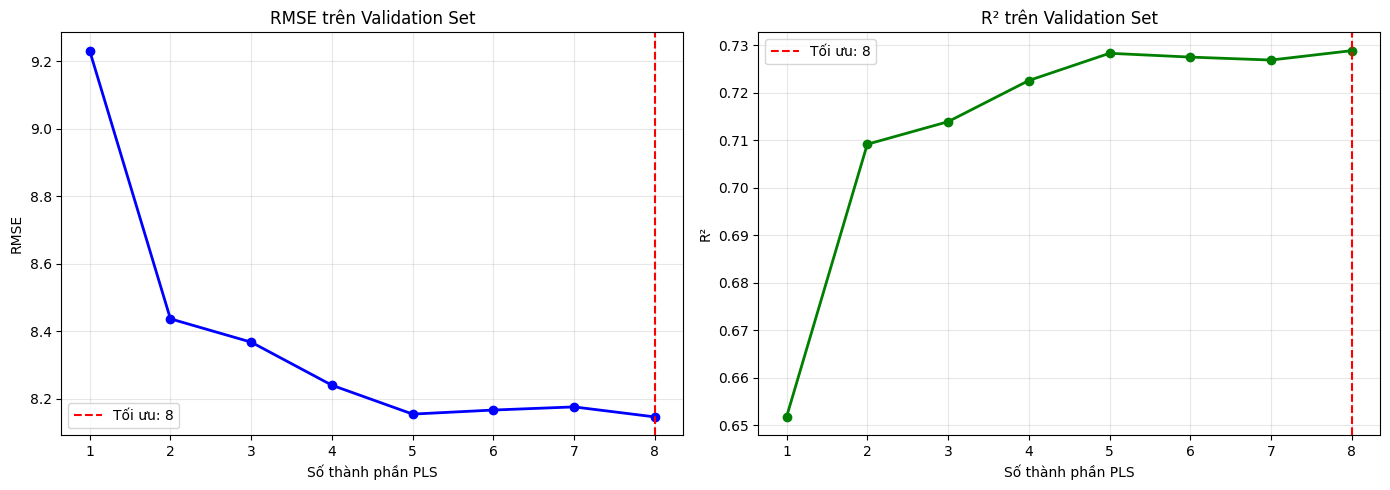


KẾT QUẢ MODEL PLS REGRESSION

Train Set:
  RMSE: 6.9819
  R²:   0.8042

Validation Set:
  RMSE: 8.1459
  R²:   0.7289

Test Set:
  RMSE: 8.3022
  R²:   0.7465


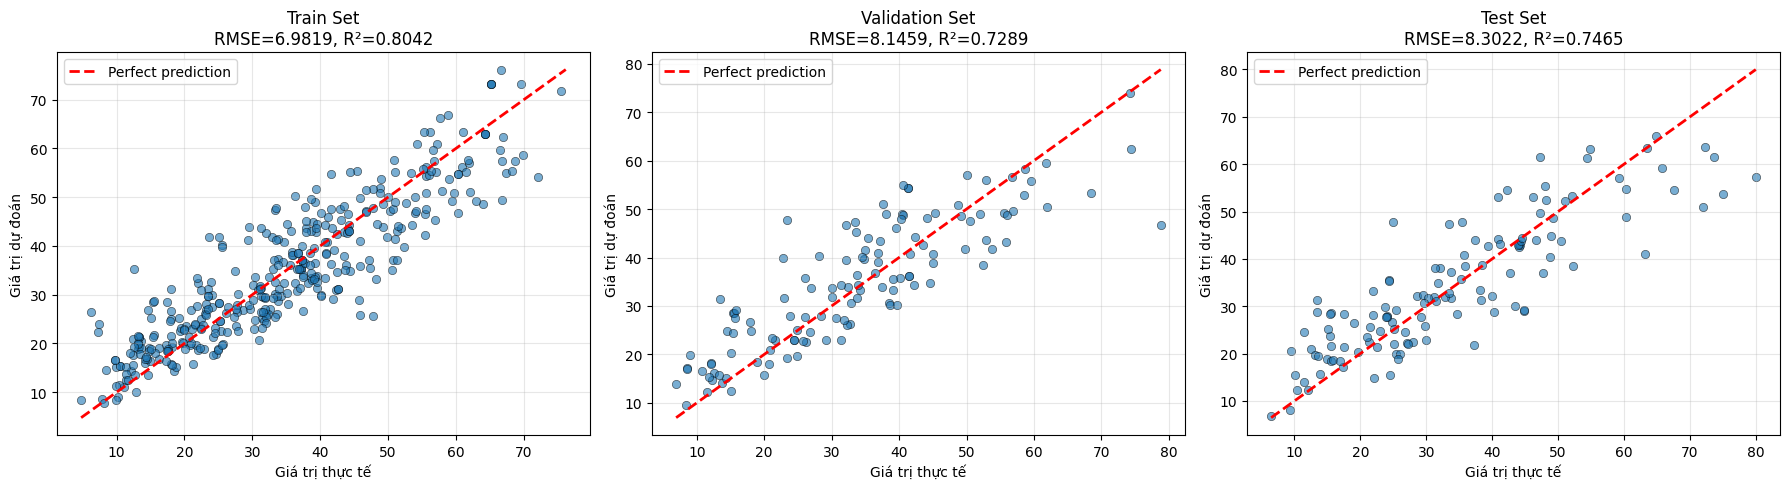


HỆ SỐ HỒI QUY PLS
Cement........................ 0.521814
Blast Furnace Slag............ 0.213137
Fly Ash....................... 0.165895
Water......................... -0.371714
Superplasticizer.............. 0.022357
Coarse Aggregate.............. -0.082858
Fine Aggregate................ -0.191778
Age........................... 0.536445


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


# Tách features và target
X = df_final.drop('Strength', axis=1)
y = df_final['Strength']

# Bước 1: Chia train (60%) và tạm thời (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# Bước 2: Chia tạm thời (40%) thành validation (20%) và test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Kích thước tập train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Kích thước tập validation: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Kích thước tập test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Chuẩn hóa dữ liệu
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

# Tìm số thành phần tối ưu bằng validation set
n_components_range = range(1, min(X_train.shape[1], 15) + 1)
val_rmse_scores = []
val_r2_scores = []

for n in n_components_range:
    pls = PLSRegression(n_components=n)
    pls.fit(X_train_scaled, y_train_scaled)
    
    y_val_pred_scaled = pls.predict(X_val_scaled)
    y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).ravel()
    
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2 = r2_score(y_val, y_val_pred)
    
    val_rmse_scores.append(rmse)
    val_r2_scores.append(r2)

# Tìm số thành phần tối ưu (RMSE thấp nhất trên validation set)
optimal_n_components = list(n_components_range)[np.argmin(val_rmse_scores)]
print(f"\nSố thành phần tối ưu: {optimal_n_components}")

# Vẽ biểu đồ validation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(n_components_range), val_rmse_scores, 'o-', color='blue', linewidth=2)
ax1.axvline(x=optimal_n_components, color='red', linestyle='--', label=f'Tối ưu: {optimal_n_components}')
ax1.set_xlabel('Số thành phần PLS')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE trên Validation Set')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(list(n_components_range), val_r2_scores, 'o-', color='green', linewidth=2)
ax2.axvline(x=optimal_n_components, color='red', linestyle='--', label=f'Tối ưu: {optimal_n_components}')
ax2.set_xlabel('Số thành phần PLS')
ax2.set_ylabel('R²')
ax2.set_title('R² trên Validation Set')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Train model cuối cùng với số thành phần tối ưu
pls_final = PLSRegression(n_components=optimal_n_components)
pls_final.fit(X_train_scaled, y_train_scaled)

# Dự đoán trên các tập dữ liệu
y_train_pred_scaled = pls_final.predict(X_train_scaled)
y_val_pred_scaled = pls_final.predict(X_val_scaled)
y_test_pred_scaled = pls_final.predict(X_test_scaled)

# Chuyển về thang đo gốc
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel()
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).ravel()
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

# Tính toán metrics
results = {
    'Train': {
        'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'R2': r2_score(y_train, y_train_pred)
    },
    'Validation': {
        'RMSE': np.sqrt(mean_squared_error(y_val, y_val_pred)),
        'R2': r2_score(y_val, y_val_pred)
    },
    'Test': {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'R2': r2_score(y_test, y_test_pred)
    }
}

# In kết quả
print("\n" + "="*60)
print("KẾT QUẢ MODEL PLS REGRESSION")
print("="*60)
for dataset, metrics in results.items():
    print(f"\n{dataset} Set:")
    print(f"  RMSE: {metrics['RMSE']:.4f}")
    print(f"  R²:   {metrics['R2']:.4f}")

# Vẽ biểu đồ dự đoán vs thực tế
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    ('Train', y_train, y_train_pred),
    ('Validation', y_val, y_val_pred),
    ('Test', y_test, y_test_pred)
]

for idx, (name, y_true, y_pred) in enumerate(datasets):
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
    
    # Đường y=x
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
    
    ax.set_xlabel('Giá trị thực tế')
    ax.set_ylabel('Giá trị dự đoán')
    ax.set_title(f'{name} Set\nRMSE={results[name]["RMSE"]:.4f}, R²={results[name]["R2"]:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# In hệ số hồi quy
print("\n" + "="*60)
print("HỆ SỐ HỒI QUY PLS")
print("="*60)

# Sửa lỗi ở đây - kiểm tra shape của coef_
coef = pls_final.coef_.flatten()  # Flatten để chuyển thành 1D array
for i, col in enumerate(X.columns):
    print(f"{col:.<30} {coef[i]:.6f}")